## Step 2: Code Roll-Up



Raw EHR codes are often highly granular, which can make analysis difficult. To enable effective comparison and analysis, standardized coding is essential. Code rollup enables mapping of granular codes from various coding systems to common parent codes, thereby ensuring standardization and harmonizing data across different institutions.

The code rollup process involves the following steps

1. **Normalize raw EHR codes to a standard vocabulary**  
   Raw EHR data often contain a mixture of standardized and local codes. When possible, map raw codes to a recognized standardized coding system using mappings provided by the host institution or accompanying EHR documentation. Few standarized codes are mentioned below 

- **Diagnoses**: ICD9-CM/ICD10-CM 
- **Medications**: RxNorm, NDC  
- **Procedures**: CPT, HCPCS, or ICD10-PCS  
- **Laboratory tests**: LOINC  

2. **Roll up standardized code to parent group codes**  
After normalization, standardized codes should be aggregated into higher level parent codes. For our tutorial, we will be using the following parent groupings

- **Diagnoses**: PheCode  
- **Medications**: RxNorm Ingredient level  
- **Procedures**: HCUP CCS categories  
- **Laboratory tests**: LOINC Component being measured 

> **Note:**  
> Its good practice to merge the mappings from the above two steps to create a single master mapping file (codebook) that links each raw EHR code to its corresponding parent code. This can be reused for future processing needs. Codes that cannot be mapped should be retained in their original form and flagged for review.
   


In [2]:
import os
import sys
import time
import logging
import pandas as pd
from tqdm import tqdm
from IPython.display import clear_output
from IPython.display import display
import os, zipfile, urllib.request
from pathlib import Path

# Set pandas options to expand all data within rows
pd.set_option('display.max_columns', None)      
pd.set_option('display.max_colwidth', None) 

#Update base directory to your EHR_TUTORIAL_WORKSPACE path
base_directory ="/n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE"

rolledup_intermediatedata_directory = os.path.join(base_directory, 'processed_data', 'step4_rolledup_intermediatedata')
os.makedirs(rolledup_intermediatedata_directory, exist_ok=True)
print(f"Directory created at: {rolledup_intermediatedata_directory}")

rolledup_finaldata_directory = os.path.join(base_directory, 'processed_data', 'step4_rolledup_finaldata')
os.makedirs(rolledup_finaldata_directory, exist_ok=True)
print(f"Directory created at: {rolledup_finaldata_directory}")

Directory created at: /n/scratch/users/v/va67/EHR_TUTORIAL_WORKSPACE/processed_data/step4_rolledup_intermediatedata
Directory created at: /n/scratch/users/v/va67/EHR_TUTORIAL_WORKSPACE/processed_data/step4_rolledup_finaldata


## Creating Rollup Mapping Files

### 1. Mapping ICD to PheCode  (Diagnoses)

**ICD** coding system (The International Classification of Diseases), maintained by the World Health Organization (WHO), provides a standardized framework for reporting diagnoses and health conditions. ICD codes are highly detailed and widely used in clinical documentation and billings. However, their granularity can make them less practical for large scale studies.  

**PheCodes** are a research-oriented grouping system designed to aggregate ICD codes into clinically meaningful phenotypes that are suitable for high-throughput analysis, such as Phenome-Wide Association Studies (PheWAS). By rolling up ICD codes to PheCodes, researchers can define reproducible phenotypes and facilitate cross-study comparisons.  

Unlike the CPT–CCS mapping, the PheCode mapping table provides direct mappings from ICD codes to PheCodes. The official mapping table can be downloaded from the PheWAS Catalog [here](https://phewascatalog.org/phewas/#phe12)


In [ ]:
#Download the ICD to PheCode mapping from the PheWAS Catalog

import os, zipfile, urllib.request
from pathlib import Path

meta_files_dir = os.path.join(base_directory, "scripts", "EHR-Processing-Tutorial-main", "meta_files")

phecode = Path(meta_files_dir, "Phecode"); phecode.mkdir(parents=True, exist_ok=True)
url = "https://phewascatalog.org/phewas/_w_916f531506bf4e0ca8b9d159d8e0f5ae/data/Phecode_map_v1_2_icd9_icd10cm.csv.zip"
zip_path = phecode / os.path.basename(url)

if not zip_path.exists(): urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path) as z: z.extractall(phecode)

print("Phecode contents:")
print(*sorted(p.name for p in phecode.iterdir()), sep="\n")

In [ ]:
def roll_icd2phe(input_path, output_path, remove_dots=True):
    # Load combined mapping (ICD-9 & ICD-10-CM) → PheCode
    cols = ['ICD', 'Flag', 'Phecode']
    df = pd.read_csv(input_path, usecols=cols, dtype=str, encoding='unicode_escape')
    df = df.apply(lambda s: s.str.strip())

    # Keep ICD-9 and ICD10 rows
    df = df[df['Flag'].isin(['9', '10'])].copy()

    # Normalize ICD code (remove dots)
    if remove_dots:
        df['ICD'] = df['ICD'].str.replace('.', '', regex=False)

    # Map flag to coding system label
    flag2sys = {'9': 'ICD9', '10': 'ICD10CM'}
    df['coding_system'] = df['Flag'].map(flag2sys)

    out = (
        df.rename(columns={'ICD': 'code', 'Phecode': 'PheCode'})
          .dropna(subset=['code', 'PheCode', 'coding_system'])
          .drop_duplicates(subset=['code', 'coding_system'], keep='first')
          .loc[:, ['code', 'PheCode', 'coding_system']]
          .sort_values(['coding_system', 'code'], kind='stable')
    )

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    out.to_csv(output_path, index=False)
    return out


base_directory = "/n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE"

input_path  = os.path.join(
    base_directory, 'scripts', 'EHR-Processing-Tutorial-main', 'meta_files',
    'Phecode', 'Phecode_map_v1_2_icd9_icd10cm.csv'
)
output_path = os.path.join(
    base_directory, 'scripts', 'EHR-Processing-Tutorial-main', 'Rollup_Mappings',
    'icd_to_phecode.csv'
)

icd_to_phe = roll_icd2phe(input_path, output_path)

print('\nICD to PheCode (first 10 rows):')
print(icd_to_phe.head(10))


### 2. Mapping CPT codes to CCS codes (Procedures)

Current Procedural Terminology (**CPT**) codes are a standardized coding system maintained by the American Medical Association to describe medical, surgical, and diagnostic procedures and services. They are widely used in billing and reimbursement but are highly granular, often resulting in thousands of distinct codes.  

Clinical Classifications Software (**CCS**) for services and procedures is a higher level grouping system developed by the Agency for Healthcare Research and Quality (AHRQ). CCS aggregates detailed CPT and ICD procedure codes into clinically meaningful categories, making them more suitable for statistical analysis and health services research.  

The official CCS mapping table often uses **range format**. For example, a range entry `'T10001–T10004' → 128` indicates that all CPT codes from T10001 through T10004 map to CCS category 128. We need to **parse and expand these ranges** so each CPT code is individually mapped to its corresponding CCS category.

You can download the official CCS mapping table for CPT/HCPCS codes from the AHRQ HCUP website [here](https://www.hcup-us.ahrq.gov/toolssoftware/ccs_svcsproc/)


In [ ]:
#Go to your meta files folder and download the mapping from HCPU website

meta_files_dir = os.path.join(base_directory, "scripts", "EHR-Processing-Tutorial-main", "meta_files")

ccs = Path(meta_files_dir, "CCS"); ccs.mkdir(parents=True, exist_ok=True)
url = "https://hcup-us.ahrq.gov/toolssoftware/ccs_svcsproc/CCS-Services_Procedures_v2025-1.zip"
zip_path = ccs / os.path.basename(url)

if not zip_path.exists(): urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path) as z: z.extractall(ccs)

print(*sorted(p.name for p in ccs.iterdir()), sep="\n")


In [ ]:
def roll_cpt2ccs(input_path, output_path):

    
    # load the original mapping table
    cols = ['Code Range','CCS','CCS Label']
    type_setting = {'Code Range':str, 'CCS': int}
    original_table = pd.read_csv(input_path, usecols=type_setting.keys(), skiprows=1,
                dtype=type_setting, index_col=False)
    
    # the final rolling-up table
    cpt2ccs = []
    
    for line in original_table.itertuples(False):
        # [a, b] is a continuous sequence of CPTs rolled up to a CCS
        a, b = line[0].strip('\'').split('-')
        ccs_code = line[1]
        
        if a == b:      # the sequence has only one CPT
            cpt2ccs.append([a, ccs_code])
        else:           # the sequence has more than one CPTs
            a = int(a)
            b = int(b)
            for i in range(a, b+1):
                cpt2ccs.append([i, ccs_code])  
    
    # output the result to a csv file
    cpt2ccs = pd.DataFrame(cpt2ccs, columns=['cpt', 'ccs'], dtype='str')
    cpt2ccs.to_csv(output_path, index=False)
    
    return cpt2ccs

input_path = os.path.join(base_directory, 'scripts', 'EHR-Processing-Tutorial-main','meta_files','CCS','CCS_Services_Procedures_v2025-1_052425.csv')
output_path = os.path.join(base_directory, 'scripts', 'EHR-Processing-Tutorial-main','Rollup_Mappings','cpt2ccs_rollup.csv')

cpt2ccs = roll_cpt2ccs(input_path,output_path)

print('\nCPT to CCS mapppings:')
print(cpt2ccs.iloc[:10, :])

### 3. Mapping ICD10-PCS and ICD9-CM Procedure codes to CCS  (Procedure)

Procedure codes in the International Classification of Diseases (ICD) system are used to document surgical and diagnostic interventions. The two main versions commonly encountered in EHR data are:  

- **ICD-9-CM (Clinical Modification):** The ninth revision, widely used in the United States prior to 2015, which includes both diagnostic and procedure codes.  
- **ICD-10-PCS (Procedure Coding System):** Introduced in 2015 to replace ICD-9-CM procedure codes, ICD-10-PCS offers a more detailed, structured system for classifying inpatient procedures.  

To enable analysis, both ICD-9-CM and ICD-10-PCS procedure codes can be aggregated into higher-level groups using the **Clinical Classifications Software (CCS)**. CCS consolidates thousands of individual procedure codes into a manageable number of clinically meaningful categories, facilitating health services research and statistical analysis.  

The official CCS mapping tables can be downloaded from the AHRQ HCUP website:  
- [ICD-9-CM CCS Mapping](https://www.hcup-us.ahrq.gov/toolssoftware/ccs/ccs.jsp)  
- [ICD-10-PCS CCS Mapping](https://www.hcup-us.ahrq.gov/toolssoftware/ccs10/ccs10.jsp)  


In [ ]:
# Download the required files

import os, urllib.request, zipfile
from pathlib import Path

base_directory = "/n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE"
meta_files_dir = os.path.join(base_directory, "scripts", "EHR-Processing-Tutorial-main", "meta_files")
ccs = Path(meta_files_dir, "CCS"); ccs.mkdir(parents=True, exist_ok=True)

urls = [
    "https://hcup-us.ahrq.gov/toolssoftware/ccs/Single_Level_CCS_2015.zip",
    "https://hcup-us.ahrq.gov/toolssoftware/ccs10/ccs_pr_icd10pcs_2020_1.zip",
]

for u in urls:
    z = ccs / os.path.basename(u)
    if not z.exists(): urllib.request.urlretrieve(u, z)
    with zipfile.ZipFile(z) as zf: zf.extractall(ccs)

print("CCS contents:")
print(*sorted(p.name for p in ccs.iterdir()), sep="\n")

In [ ]:
# Generate the mapping file

def roll_icd_procedures_to_ccs(icd10pcs_input_path,
                               icd9cm_input_path,
                               output_path,
                               icd9_skiprows=1):
    """
    Build a single rollup file mapping ICD-9-CM and ICD-10-PCS procedure codes to CCS.
    Output schema: code,ccs,coding_system  (coding_system ∈ {ICD9CM, ICD10PCS})
    """

    def _normalize_cols(df):
        df.columns = [c.strip().strip("'").strip('"') for c in df.columns]
        return df

    # -------- ICD-10-PCS → CCS --------
    df10 = pd.read_csv(icd10pcs_input_path, dtype=str, encoding='utf8', index_col=False)
    df10 = _normalize_cols(df10)
    need10 = ['ICD-10-PCS CODE', 'CCS CATEGORY']
    if not set(need10).issubset(df10.columns):
        missing = [c for c in need10 if c not in df10.columns]
        raise ValueError(f"ICD-10-PCS file missing required columns: {missing}")
    df10 = (df10[need10]
            .rename(columns={'ICD-10-PCS CODE': 'code', 'CCS CATEGORY': 'ccs'}))
    for col in ['code', 'ccs']:
        df10[col] = df10[col].str.replace("'", "", regex=False).str.strip()
    df10.dropna(subset=['code', 'ccs'], inplace=True)
    df10.drop_duplicates(subset=['code'], keep='first', inplace=True)
    df10['coding_system'] = 'ICD10PCS'

    # -------- ICD-9-CM → CCS --------
    df9 = pd.read_csv(icd9cm_input_path, dtype=str, encoding='utf8',
                      index_col=False, skiprows=icd9_skiprows)
    df9 = _normalize_cols(df9)
    need9 = ['ICD-9-CM CODE', 'CCS CATEGORY']
    if not set(need9).issubset(df9.columns):
        missing = [c for c in need9 if c not in df9.columns]
        raise ValueError(f"ICD-9-CM file missing required columns: {missing}")
    df9 = (df9[need9]
           .rename(columns={'ICD-9-CM CODE': 'code', 'CCS CATEGORY': 'ccs'}))
    for col in ['code', 'ccs']:
        df9[col] = df9[col].str.replace("'", "", regex=False).str.strip()
    df9.dropna(subset=['code', 'ccs'], inplace=True)
    df9 = df9[df9['ccs'] != '0']  # match your original filter
    df9.drop_duplicates(subset=['code'], keep='first', inplace=True)
    df9['coding_system'] = 'ICD9CM'

    # -------- Combine → single file --------
    out = pd.concat([df9, df10], ignore_index=True)
    out.drop_duplicates(subset=['code', 'coding_system'], keep='first', inplace=True)
    out = out[['code', 'ccs', 'coding_system']].sort_values(['coding_system', 'code'], kind='stable')

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    out.to_csv(output_path, index=False)
    return out


# ---------- Example usage ----------
base_directory = "/n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE"

icd10pcs_input = os.path.join(
    base_directory, 'scripts', 'EHR-Processing-Tutorial-main', 'meta_files',
    'CCS', 'ccs_pr_icd10pcs_2020_1.csv'
)
icd9cm_input = os.path.join(
    base_directory, 'scripts', 'EHR-Processing-Tutorial-main', 'meta_files',
    'CCS', '$prref 2015.csv'
)
output_path = os.path.join(
    base_directory, 'scripts', 'EHR-Processing-Tutorial-main', 'Rollup_Mappings',
    'icd_procedures_to_ccs.csv'
)

icd_proc_to_ccs = roll_icd_procedures_to_ccs(icd10pcs_input, icd9cm_input, output_path)

print('\nICD Procedures to CCS sample:')
display(icd_proc_to_ccs)

In [ ]:
# Merge the procedure mappings to create a single CCS mapping file

cpt_path = os.path.join(
    base_directory, "scripts", "EHR-Processing-Tutorial-main", "Rollup_Mappings", "cpt2ccs_rollup.csv"
)
icdproc_path = os.path.join(
    base_directory, "scripts", "EHR-Processing-Tutorial-main", "Rollup_Mappings", "icd_procedures_to_ccs.csv"
)
output_path = os.path.join(
    base_directory, "scripts", "EHR-Processing-Tutorial-main", "Rollup_Mappings", "HCPCS_ICDPROC_to_CCS.csv"
)

df_cpt = pd.read_csv(cpt_path, dtype=str)
df_icd = pd.read_csv(icdproc_path, dtype=str)
df_cpt = df_cpt.rename(columns={"cpt": "code"})[["code", "ccs"]]
df_cpt["coding_system"] = "HCPCS"
merged = pd.concat([df_cpt, df_icd], ignore_index=True)
os.makedirs(os.path.dirname(output_path), exist_ok=True)
merged.to_csv(output_path, index=False)
display(merged)

### 4. Mapping NDC to RxNorm (Medication)

**National Drug Code (NDC)** system, maintained by the U.S. Food and Drug Administration (FDA), is a standardized drug identifier code. Each NDC is a unique 10/11 digit code that specifies the labeler, product, and package size. While precise for billing and dispensing, NDCs are highly granular, often resulting in thousands of codes for essentially the same drug ingredient.  

**RxNorm**, developed and maintained by the U.S. National Library of Medicine (NLM), provides normalized names and identifiers for clinical drugs and links them to many of the drug vocabularies commonly used in pharmacy management and EHR systems. Importantly, RxNorm includes mappings to **ingredient-level concepts**, which allow aggregation of NDC codes into clinically meaningful categories for research.  

The roll-up process from NDC to RxNorm involves two main step:

1. **Map RxNorm codes to their ingredients.**  
   Use the ingredient mapping table to link each RxNorm drug identifier to its corresponding active ingredient. This step reduces redundancy and ensures consistent representation of medications.  

2. **Aggregate NDC codes to RxNorm.**  
   Using the RxNorm source files (specifically `RXSAT.RRF`), link each NDC to its corresponding RxNorm code. Both *obsolete* and *non-obsolete* mappings should be included, as datasets such as MIMIC (2008–2019) may reference drugs whose mappings have since been retired. Including obsolete mappings increases coverage and improves accuracy of drug aggregation.  

Because RxNorm explicitly encodes the relationship between NDCs and RxNorm identifiers, no additional operations are required beyond incorporating obsolete mappings and linking to ingredient concepts.  

The official RxNorm release files can be downloaded from the U.S. National Library of Medicine [here](https://www.nlm.nih.gov/research/umls/rxnorm/docs/rxnormfiles.html).  


In [ ]:
# Creating the NDC code to RxNorm code mapping

def roll_ndc2rxnorm(rxnsat_path, ingredient_path, output_path):
    """
    Build NDC → RxNorm mapping using RXNSAT.RRF and an ingredient rollup table.
    Output schema: ndc,rxcui
    """
    print("Generating NDC to RxNorm mapping table...")

    # --- Load RXNSAT (keep only required columns) ---
    cols_all = ['RXCUI','LUI','SUI','RXAUI','STYPE','CODE','ATUI','SATUI','ATN','SAB','ATV','SUPPRESS','CVF']
    keep_cols = ['RXCUI', 'SUPPRESS', 'ATN', 'SAB', 'ATV']
    rxnsat = pd.read_csv(
        rxnsat_path,
        sep='|',
        header=None,
        names=cols_all,
        usecols=keep_cols,
        dtype={c: str for c in keep_cols},
        engine='python'
    )
    print('total rows:', rxnsat.shape[0])

    rxnsat = rxnsat.loc[rxnsat['ATN'] == 'NDC'].copy()
    print('unique CUIs in NDC rows:', rxnsat['RXCUI'].nunique())

    valid_mask = (rxnsat['SAB'] == 'RXNORM') & (rxnsat['SUPPRESS'] == 'N')
    table_valid = rxnsat.loc[valid_mask].copy()
    table_obsolete = rxnsat.loc[~valid_mask].copy()
    print('valid table size:', table_valid.shape[0])


    table_obsolete = table_obsolete.loc[
        (table_obsolete['ATV'].str.len() == 11) & (table_obsolete['ATV'].str.isdigit())
    ].copy()
    print('obsolete table size:', table_obsolete.shape[0])


    table = pd.concat([table_valid, table_obsolete], ignore_index=True)
    table.drop_duplicates(subset=['ATV'], keep='first', inplace=True)
    print('final size:', table.shape[0])
    print('final unique CUIs:', table['RXCUI'].nunique())

    ing = pd.read_csv(ingredient_path, usecols=['base', 'ingredient'], dtype=str)
    base2ing = dict(zip(ing['base'], ing['ingredient']))
    table['RXCUI'] = table['RXCUI'].map(lambda x: base2ing.get(x, x))


    out = (table.loc[:, ['ATV', 'RXCUI']]
                .rename(columns={'ATV': 'ndc', 'RXCUI': 'rxcui'})
                .drop_duplicates())


    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    out.to_csv(output_path, index=False)

    return out


base_directory = "/n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE"

rxnsat_path = os.path.join(
    base_directory, 'scripts', 'EHR-Processing-Tutorial-main', 'meta_files',
    'rxnorm', 'rrf', 'RXNSAT.RRF'
)
ingredient_path = os.path.join(
    base_directory, 'scripts', 'EHR-Processing-Tutorial-main', 'meta_files',
    'rxnorm', 'ingredient.csv'
)
output_path = os.path.join(
    base_directory, 'scripts', 'EHR-Processing-Tutorial-main', 'Rollup_Mappings',
    'NDC_to_RxNorm.csv'
)

ndc2rxnorm = roll_ndc2rxnorm(rxnsat_path, ingredient_path, output_path)

print('\nNDC to RxNorm mapping:')
display(ndc2rxnorm)


## Performing Roll up

### 1. Rolling up Diagnoses Data
ICD codes are highly granular. Distinguishing between minor variations of a disease is often not useful for broad research analyses and can lead to sparse data. Phecodes solves this problem by grouping relevant ICD codes into clinically meaningful phenotypes.

- The following is an illustration of how multiple ICD codes at different levels rolls up to intestinal infection PheCode. 
 


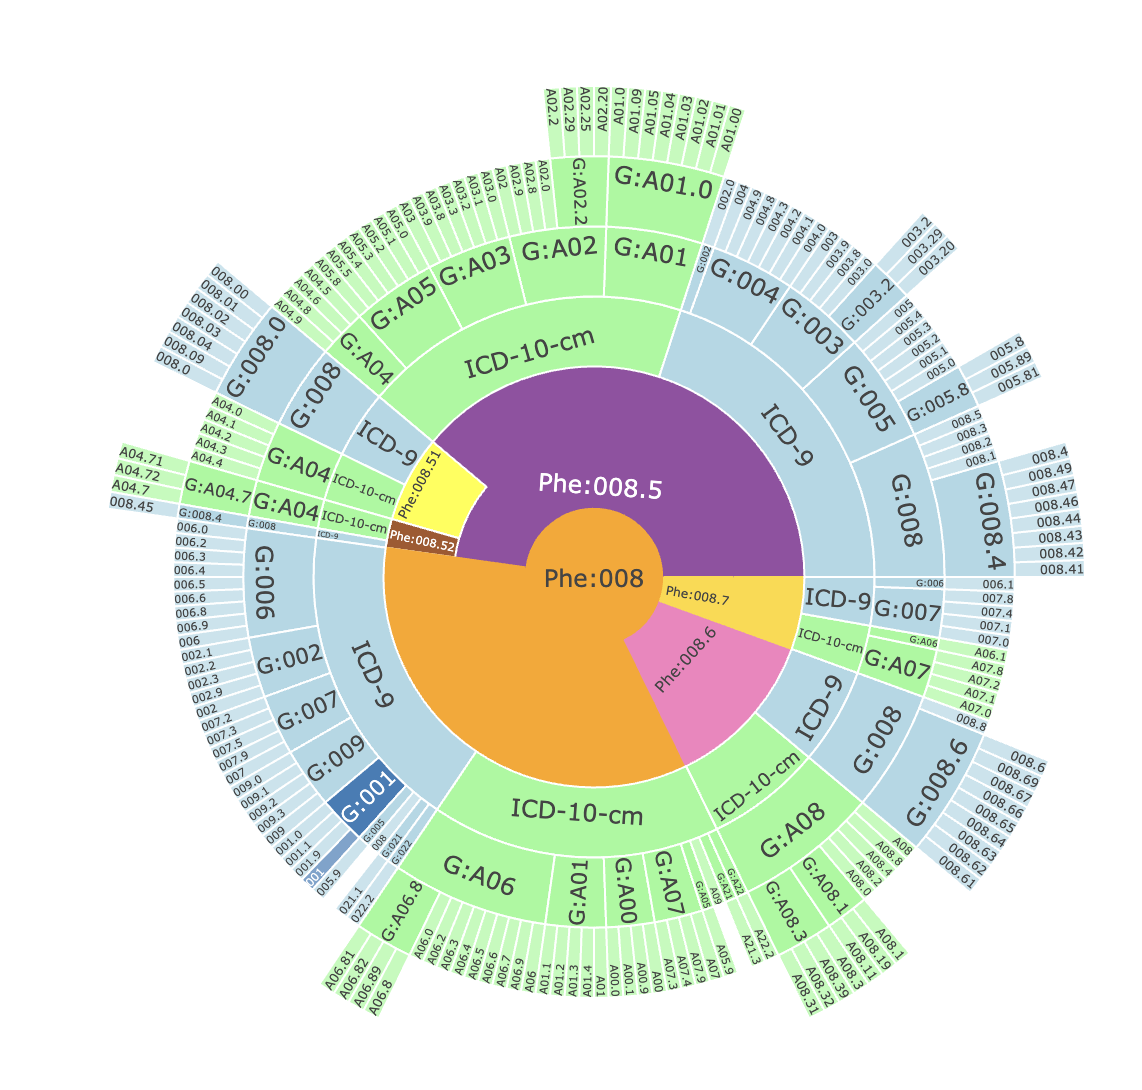

An interactive visualization of the ICD–PheCode hierarchy is available through the following online tool: [ICD–PheCode Hierarchy Viewer](https://shiny.parse-health.org/hierarchies/icd-hierarchy/).  
Next, we will go ahead and roll up the MIMIC-IV diagnosis data to Phecode

In [3]:
base_directory = os.path.dirname(os.getcwd())

icd_to_phecode_file = os.path.join(base_directory, 'scripts', 'rollup_mappings',"icd_to_phecode.csv")
icd_to_phecode = pd.read_csv(icd_to_phecode_file, dtype=str)
display(icd_to_phecode.head())

,code,PheCode,coding_system
0,001,008,ICD9
1,0010,008,ICD9
2,0011,008,ICD9
3,0019,008,ICD9
4,002,008,ICD9


In [4]:
# We will select a sample diagnoses file for rolling up

base_directory = os.path.dirname(os.getcwd())

diagnoses_cleaned_rawdata = os.path.join(base_directory, 'processed_data', 'step3_cleaned_rawdata',"Diagnoses")
diagnoses_files = os.listdir(diagnoses_cleaned_rawdata)

sample_diagnoses_filepath= os.path.join(diagnoses_cleaned_rawdata, diagnoses_files[0])
sample_diagnoses = pd.read_csv(sample_diagnoses_filepath, dtype=str)
display(sample_diagnoses.head())

,subject_id,date,code,coding_system
0,10000032,2180-05-06,5723,ICD9
1,10000032,2180-05-06,78959,ICD9
2,10000032,2180-05-06,5715,ICD9
3,10000032,2180-05-06,07070,ICD9
4,10000032,2180-05-06,496,ICD9


Merge the two tables to roll up MIMIC-IV diagnoses data to PheCodes, and save the resulting dataset in the *intermediate* folder. If, in the future, you update the roll up mappings to include more comprehensive coverage or wish to examine unmapped codes, you can return to this step and regenerate the mapping

In [5]:
# Merging the two tables to rollup/map icd code to phecode. Save this rolled up data in intermediate folder. 
# In future if you update rollup mapping to be more comprehensive or if you want to look at codes that are unmapped, you can always come back.
    
sample_diagnoses_phecode = pd.merge(sample_diagnoses, icd_to_phecode, how='left', on=['code','coding_system'])
sample_diagnoses_phecode['Rollup_Status'] = sample_diagnoses_phecode['PheCode'].notna().replace({True: '1', False: '0'})
display(sample_diagnoses_phecode.head())
print(sample_diagnoses_phecode.shape)

,subject_id,date,code,coding_system,PheCode,Rollup_Status
0,10000032,2180-05-06,5723,ICD9,571.81,1
1,10000032,2180-05-06,78959,ICD9,572,1
2,10000032,2180-05-06,5715,ICD9,571.51,1
3,10000032,2180-05-06,07070,ICD9,070.3,1
4,10000032,2180-05-06,496,ICD9,496,1


(799778, 6)


In [6]:
# Unrolled rows (where ICD codes were not rolled up)

sample_diagnoses_unrolled = sample_diagnoses_phecode[sample_diagnoses_phecode["Rollup_Status"]=="0"]
display(sample_diagnoses_unrolled.head())
print(sample_diagnoses_unrolled.shape)

,subject_id,date,code,coding_system,PheCode,Rollup_Status
34,10000032,2180-07-23,V4986,ICD9,NaN,0
44,10001319,2135-07-20,V270,ICD9,NaN,0
46,10001319,2138-11-09,V270,ICD9,NaN,0
48,10001319,2134-04-15,V270,ICD9,NaN,0
52,10001843,2131-11-09,Y840,ICD10,NaN,0


(52416, 6)


In [7]:
# Summarize the codes that have not been rolledup

unique_subject_icd_pairs = sample_diagnoses_unrolled[['subject_id', 'code','coding_system']].drop_duplicates()

icdcode_frequencies = unique_subject_icd_pairs[['code','coding_system']].value_counts().reset_index(name='counts')

sorted_icdcode_frequencies = icdcode_frequencies.rename(columns={'index': 'code'}).sort_values(by='counts', ascending=False)

display(sorted_icdcode_frequencies.head(10))

,code,coding_system,counts
0,Z20822,ICD10,3009
1,Y929,ICD10,1956
2,Y92230,ICD10,1115
3,V270,ICD9,1086
4,V4986,ICD9,1057
5,Y92009,ICD10,901
6,Y92239,ICD10,898
7,E8497,ICD9,867
8,E8490,ICD9,743
9,E8788,ICD9,694


Once the rollup is complete and the results look reasonable, you can save the data. You can save the comprehensive data with rolled and unrolled info into the intermediate_data folder. You can come back to this if you need to check anything in the future. After performing the rollup, we do not need all of the original columns. In the code below, we keep only the necessary columns

We don't really need all the columns after rollup is performed. Below we just keep the data we need.

In [8]:
sample_diagnoses_phecode_filtered = sample_diagnoses_phecode[sample_diagnoses_phecode['Rollup_Status']=="1"]

print(sample_diagnoses_phecode_filtered )
sample_diagnoses_phecode_filtered  = sample_diagnoses_phecode_filtered [['subject_id','PheCode','date']]
sample_diagnoses_phecode_filtered 

       subject_id        date    code coding_system PheCode Rollup_Status
0        10000032  2180-05-06    5723          ICD9  571.81             1
1        10000032  2180-05-06   78959          ICD9     572             1
2        10000032  2180-05-06    5715          ICD9  571.51             1
3        10000032  2180-05-06   07070          ICD9   070.3             1
4        10000032  2180-05-06     496          ICD9     496             1
...           ...         ...     ...           ...     ...           ...
799773   19999784  2121-01-31   Z5111         ICD10    1010             1
799774   19999784  2121-01-31   C8589         ICD10   202.2             1
799775   19999784  2121-01-31    E876         ICD10  276.14             1
799776   19999784  2121-01-31  Z87891         ICD10     318             1
799777   19999784  2121-01-31   Z8619         ICD10     136             1

[747362 rows x 6 columns]


,subject_id,PheCode,date
0,10000032,571.81,2180-05-06
1,10000032,572,2180-05-06
2,10000032,571.51,2180-05-06
3,10000032,070.3,2180-05-06
4,10000032,496,2180-05-06
...,...,...,...
799773,19999784,1010,2121-01-31
799774,19999784,202.2,2121-01-31
799775,19999784,276.14,2121-01-31
799776,19999784,318,2121-01-31


In [9]:
if sample_diagnoses_phecode_filtered.duplicated().sum() > 0:
    print("Duplicate rows found. Removing duplicates...")
    sample_diagnoses_phecode_filtered = sample_diagnoses_phecode_filtered.drop_duplicates()  # Remove duplicate rows
    print("DataFrame after removing duplicates:")
else:
    print("No duplicate rows found.")

display(sample_diagnoses_phecode_filtered)

Duplicate rows found. Removing duplicates...
DataFrame after removing duplicates:


,subject_id,PheCode,date
0,10000032,571.81,2180-05-06
1,10000032,572,2180-05-06
2,10000032,571.51,2180-05-06
3,10000032,070.3,2180-05-06
4,10000032,496,2180-05-06
...,...,...,...
799773,19999784,1010,2121-01-31
799774,19999784,202.2,2121-01-31
799775,19999784,276.14,2121-01-31
799776,19999784,318,2121-01-31


The complete tutorial notebook describing the data cleaning process for procedures, medications, and laboratory data is available [here](https://github.com/celehs/PEHRT/blob/main/TUTORIAL/EHR_Preprocessing_2_Code_Rollup.ipynb).  

To access the full collection of tutorial notebooks, tools, visualizations, and relevant metadata files, please register [here](https://harvard.az1.qualtrics.com/jfe/form/SV_6WJERAowyHA9by6).